In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import random

# Import the LOO metrics function and plotting helpers
from malca.utils import compute_camera_loo_metrics
from malca.lightcurve_io import read_lc_dat2


In [2]:
# Configuration
BUNDLE_DIR = Path("/home/calder/code/malca/output/runs/runs_march18_bundle_all/bundle_assets/lightcurves")
N_LIGHTCURVES = 200

# Get all available light curves
all_lc_paths = list(BUNDLE_DIR.glob("*.dat3"))
if not all_lc_paths:
    all_lc_paths = list(BUNDLE_DIR.glob("*.dat2"))
    
print(f"Found {len(all_lc_paths)} light curves. Sampling {min(N_LIGHTCURVES, len(all_lc_paths))}...")

# Set random seed for reproducibility
random.seed(42)
sampled_paths = random.sample(all_lc_paths, min(N_LIGHTCURVES, len(all_lc_paths)))


Found 9569 light curves. Sampling 200...


In [3]:
# Calculate LOO metrics for the sample
results = []
bad_lcs = []

for path in tqdm(sampled_paths):
    candidate_id = path.stem
    # read_lc_dat2 expects the id and directory. Since we have dat3, we might need a custom load if read_lc_dat2 doesn't support it directly, but read_lc_dat2 falls back to dat2/dat3
    df_g, df_v = read_lc_dat2(candidate_id, str(BUNDLE_DIR), file_ext=path.suffix[1:])
    
    # We will compute metrics for whichever band has more points (usually g or V)
    df = df_g if len(df_g) > len(df_v) else df_v
    
    if df.empty or "camera#" not in df.columns:
        bad_lcs.append(candidate_id)
        continue
        
    try:
        # Compute LOO metrics for each camera
        loo_res = compute_camera_loo_metrics(df, cam_col="camera#")
        if not loo_res:
            continue
            
        # Parse results
        for cam_id, metrics in loo_res.items():
            results.append({
                "candidate_id": candidate_id,
                "camera_id": cam_id,
                "loo_corr": metrics.get("corr", np.nan),
                "loo_offset": metrics.get("offset", np.nan),
                "loo_rms": metrics.get("rms", np.nan),
                "n_points": len(df[df["camera#"] == cam_id])
            })
    except Exception as e:
        print(f"Failed on {candidate_id}: {e}")
        bad_lcs.append(candidate_id)
        
metrics_df = pd.DataFrame(results)
print(f"Processed {len(metrics_df['candidate_id'].unique())} valid light curves, resulting in {len(metrics_df)} camera evaluations.")
if bad_lcs:
    print(f"Skipped {len(bad_lcs)} invalid/empty light curves.")


  0%|          | 0/200 [00:00<?, ?it/s]

Processed 200 valid light curves, resulting in 912 camera evaluations.


In [4]:
# Quick view of the metrics table
display(metrics_df.head(10))


,candidate_id,camera_id,loo_corr,loo_offset,loo_rms,n_points
0,8590392531,4,NaN,0.000617,NaN,0
1,8590392531,5,NaN,0.003250,NaN,0
2,8590392531,6,NaN,0.000216,NaN,0
3,8590392531,7,NaN,0.000513,NaN,0
4,8590392531,8,0.020085,0.001221,0.196987,0
5,8590392531,9,NaN,0.004516,NaN,0
6,163209494750,2,NaN,0.021763,NaN,0
7,163209494750,3,NaN,-0.000983,NaN,0
8,163209494750,4,NaN,0.003914,NaN,0
9,163209494750,5,NaN,0.023360,NaN,0


In [5]:
# Aggregate by camera
camera_stats = metrics_df.groupby("camera_id").agg(
    n_evals=("candidate_id", "count"),
    median_loo_corr=("loo_corr", "median"),
    median_loo_offset=("loo_offset", "median"),
    median_loo_rms=("loo_rms", "median"),
    total_points=("n_points", "sum")
).sort_values("median_loo_corr", ascending=True)

display(camera_stats[camera_stats['n_evals'] > 5].head(15)) # Worst 15 cameras by correlation


,n_evals,median_loo_corr,median_loo_offset,median_loo_rms,total_points
camera_id,,,,,
12,9,-0.052744,-0.002268,0.084205,0
6,118,0.043092,0.001440,0.073045,0
2,103,0.087215,0.008685,0.059519,0
5,129,0.122142,0.001241,0.069597,0
3,175,0.126452,0.004707,0.092838,0
7,88,0.128785,0.000731,0.088476,0
8,52,0.158391,0.000980,0.091614,0
9,22,0.176187,0.000354,0.094693,0
4,169,0.196116,0.002164,0.087424,0


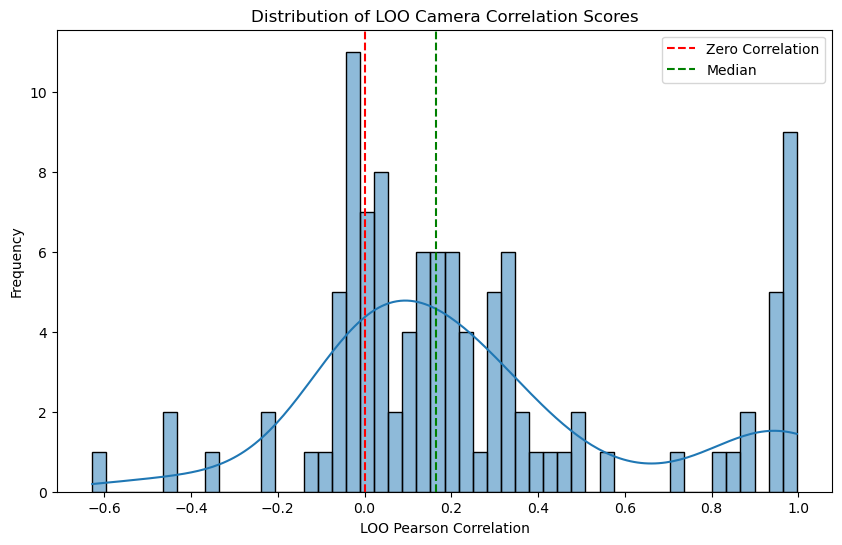

In [6]:
# Distribution of LOO Correlation Scores
plt.figure(figsize=(10, 6))
sns.histplot(data=metrics_df.dropna(subset=['loo_corr']), x='loo_corr', bins=50, kde=True)
plt.title("Distribution of LOO Camera Correlation Scores")
plt.xlabel("LOO Pearson Correlation")
plt.ylabel("Frequency")
plt.axvline(0, color='r', linestyle='--', label='Zero Correlation')
plt.axvline(metrics_df['loo_corr'].median(), color='g', linestyle='--', label='Median')
plt.legend()
plt.show()


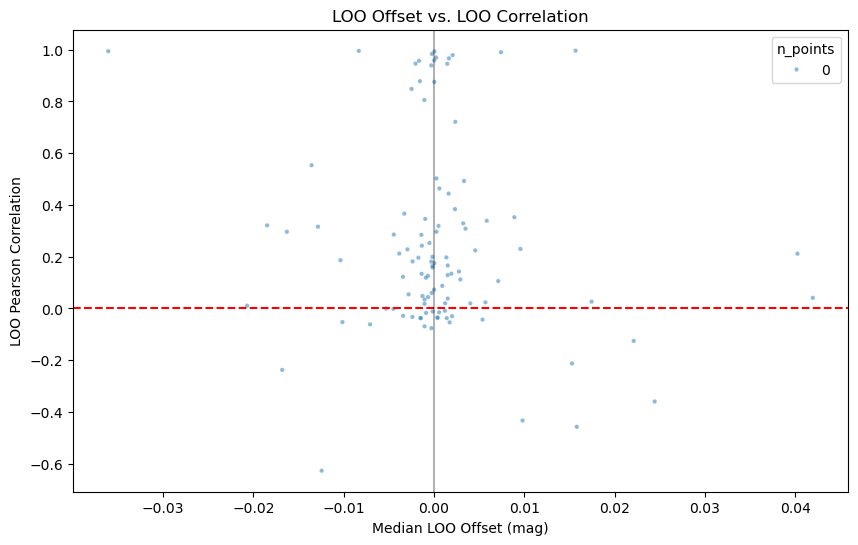

In [7]:
# Offset vs Correlation (Are offset cameras less correlated?)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=metrics_df, x='loo_offset', y='loo_corr', alpha=0.5, size='n_points', sizes=(10, 200))
plt.title("LOO Offset vs. LOO Correlation")
plt.xlabel("Median LOO Offset (mag)")
plt.ylabel("LOO Pearson Correlation")
plt.axhline(0, color='r', linestyle='--')
plt.axvline(0, color='k', linestyle='-', alpha=0.3)
plt.show()


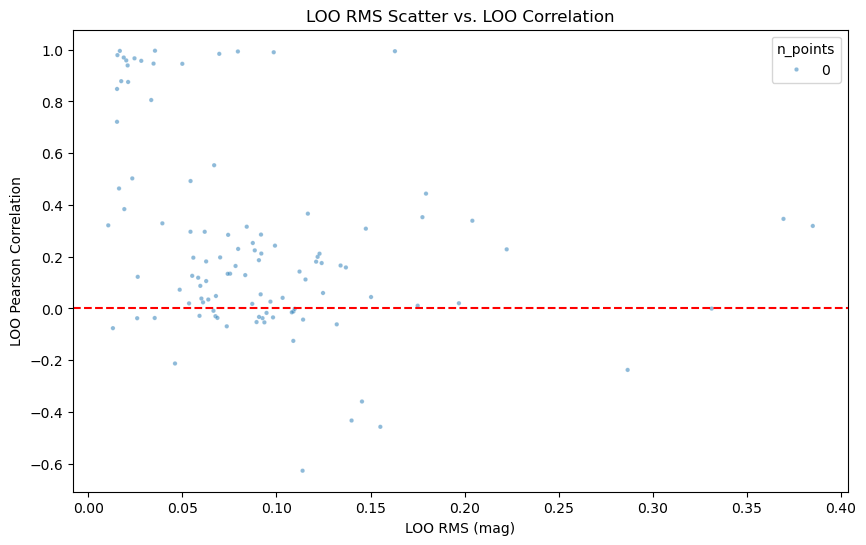

In [8]:
# RMS vs Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=metrics_df, x='loo_rms', y='loo_corr', alpha=0.5, size='n_points', sizes=(10, 200))
plt.title("LOO RMS Scatter vs. LOO Correlation")
plt.xlabel("LOO RMS (mag)")
plt.ylabel("LOO Pearson Correlation")
plt.axhline(0, color='r', linestyle='--')
plt.show()


Visualizing Light Curve 17180843162
Focusing on Camera 5 (LOO Corr: -0.627, RMS: 0.114)


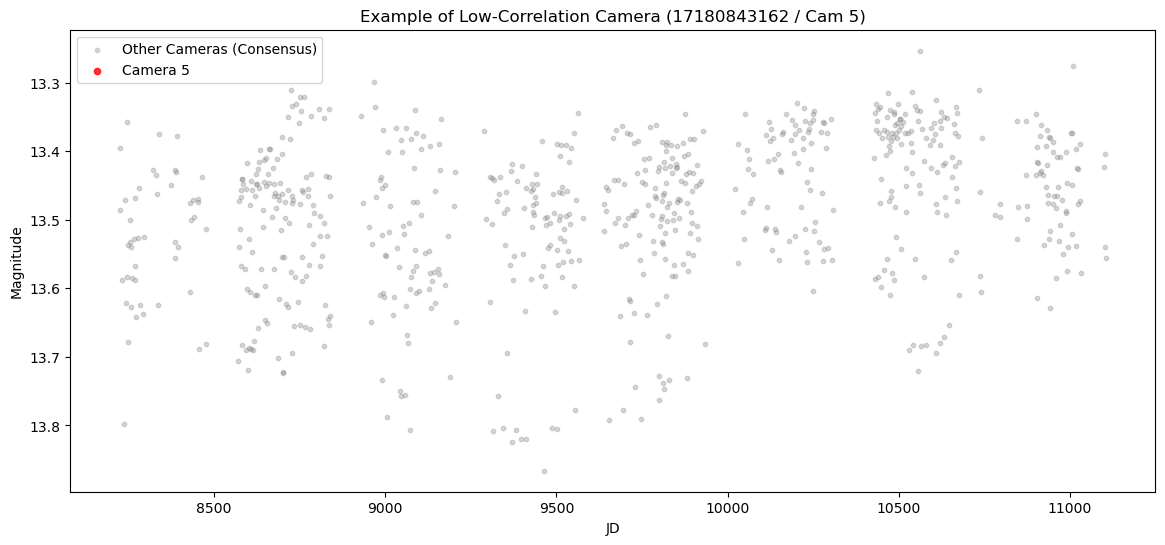

In [9]:
# Let's visualize an example of a BAD camera
bad_camera_evals = metrics_df[(metrics_df['loo_corr'] < 0.2) ]
if not bad_camera_evals.empty:
    worst_example = bad_camera_evals.sort_values('loo_corr').iloc[0]
    candidate_id = worst_example['candidate_id']
    bad_cam = worst_example['camera_id']
    
    print(f"Visualizing Light Curve {candidate_id}")
    print(f"Focusing on Camera {bad_cam} (LOO Corr: {worst_example['loo_corr']:.3f}, RMS: {worst_example['loo_rms']:.3f})")
    
    df_g, df_v = read_lc_dat2(candidate_id, str(BUNDLE_DIR), file_ext="dat3")
    df = df_g if len(df_g) > len(df_v) else df_v
    df['JD'] = pd.to_numeric(df['JD'], errors='coerce')
    df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
    
    plt.figure(figsize=(14, 6))
    
    # Plot all other cameras
    other_cams = df[df["camera#"] != bad_cam]
    plt.scatter(other_cams['JD'], other_cams['mag'], color='gray', alpha=0.3, s=10, label='Other Cameras (Consensus)')
    
    # Plot the bad camera
    bad_cam_df = df[df["camera#"] == bad_cam]
    plt.scatter(bad_cam_df['JD'], bad_cam_df['mag'], color='red', alpha=0.8, s=20, label=f'Camera {bad_cam}')
    
    plt.gca().invert_yaxis()
    plt.title(f"Example of Low-Correlation Camera ({candidate_id} / Cam {bad_cam})")
    plt.xlabel("JD")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.show()
else:
    print("No severely bad cameras found in this random sample!")


Visualizing Light Curve 8590954303
Focusing on Camera 4 (LOO Corr: 0.996, RMS: 0.035)


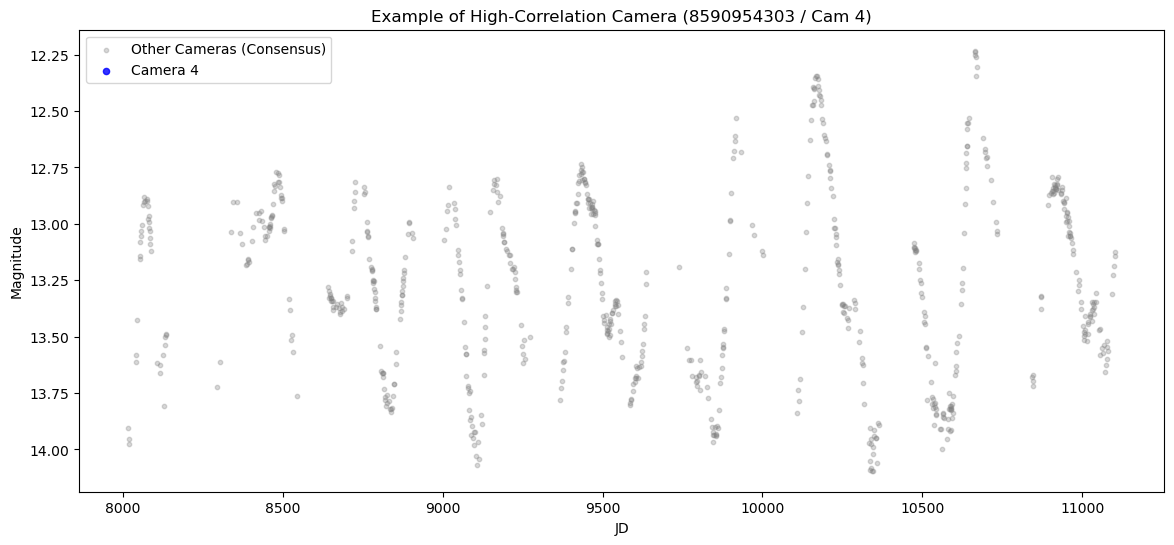

In [10]:
# Let's visualize an example of a GOOD camera
good_camera_evals = metrics_df[(metrics_df['loo_corr'] > 0.7) ]
if not good_camera_evals.empty:
    best_example = good_camera_evals.sort_values('loo_corr', ascending=False).iloc[0]
    candidate_id = best_example['candidate_id']
    good_cam = best_example['camera_id']
    
    print(f"Visualizing Light Curve {candidate_id}")
    print(f"Focusing on Camera {good_cam} (LOO Corr: {best_example['loo_corr']:.3f}, RMS: {best_example['loo_rms']:.3f})")
    
    df_g, df_v = read_lc_dat2(candidate_id, str(BUNDLE_DIR), file_ext="dat3")
    df = df_g if len(df_g) > len(df_v) else df_v
    df['JD'] = pd.to_numeric(df['JD'], errors='coerce')
    df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
    
    plt.figure(figsize=(14, 6))
    
    # Plot all other cameras
    other_cams = df[df["camera#"] != good_cam]
    plt.scatter(other_cams['JD'], other_cams['mag'], color='gray', alpha=0.3, s=10, label='Other Cameras (Consensus)')
    
    # Plot the good camera
    good_cam_df = df[df["camera#"] == good_cam]
    plt.scatter(good_cam_df['JD'], good_cam_df['mag'], color='blue', alpha=0.8, s=20, label=f'Camera {good_cam}')
    
    plt.gca().invert_yaxis()
    plt.title(f"Example of High-Correlation Camera ({candidate_id} / Cam {good_cam})")
    plt.xlabel("JD")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.show()
else:
    print("No extremely good cameras found in this random sample!")
